In [2]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Early-Sepsis-Detection"

Mounted at /content/drive
/content/drive/MyDrive/Early-Sepsis-Detection


In [3]:
import importlib
from src import target as tgt
importlib.reload(tgt)

<module 'src.target' from '/content/drive/MyDrive/Early-Sepsis-Detection/src/target.py'>

# 06 — Target Construction
### Early Sepsis Detection — Phase 7 (CRITICAL — read before Phase 8)

**Goal:** Understand exactly how `SepsisLabel` behaves in this specific
downloaded dataset, and define a leakage-safe patient-level prediction
task BEFORE any feature engineering happens.

We do NOT assume the official Challenge onset formula from memory — we
verify observable label behavior empirically against the real data first.


In [4]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import target as tgt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


In [5]:
df = pd.read_parquet(config.INTERIM_DIR / "sepsis_hourly_cleaned.parquet")
print("Loaded shape:", df.shape)


Loaded shape: (1552210, 45)


## 1. Verify label monotonicity

**What?** Check whether `SepsisLabel` ever goes from 1 back to 0 for any
patient. If it never does, we can treat "onset hour" (first hour label=1)
as a well-defined, stable event per patient.


In [6]:
bad_patients_df = tgt.verify_label_monotonicity(df)
n_bad = bad_patients_df[config.PATIENT_ID_COL].nunique() if len(bad_patients_df) else 0
print(f"Patients with a 1->0 SepsisLabel transition: {n_bad}")
if n_bad:
    display(bad_patients_df[[config.PATIENT_ID_COL, "ICULOS", config.TARGET_COL]].head(20))


2026-09-14 06:00:27,527 | INFO | src.target | Verified: no patient has a SepsisLabel 1->0 transition (monotonic non-decreasing label confirmed for all 40336 patients).
INFO:src.target:Verified: no patient has a SepsisLabel 1->0 transition (monotonic non-decreasing label confirmed for all 40336 patients).


Patients with a 1->0 SepsisLabel transition: 0


## 2. Onset-hour distribution

**What?** For every sepsis-positive patient, the first ICU hour at which
`SepsisLabel == 1`.

**Why?** This tells us how much "pre-onset" history typically exists —
directly informing whether a 6/12/24-hour prediction window is even
feasible for most positive patients.


count    2932.000000
mean       50.896317
std        59.363708
min         1.000000
25%         7.000000
50%        29.000000
75%        73.000000
max       331.000000
Name: onset_hour, dtype: float64


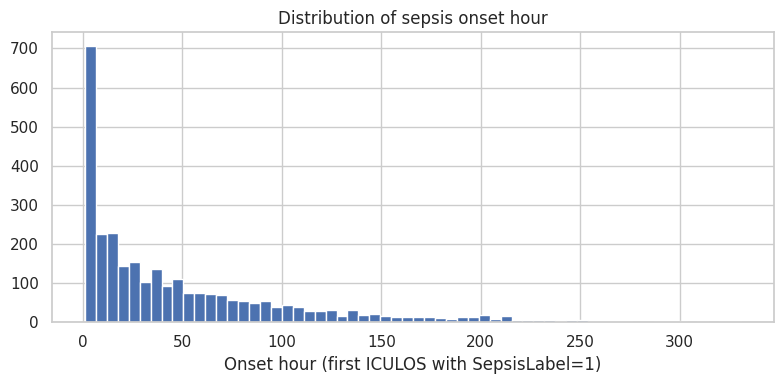


Window=6h: 706/2932 positive patients have onset at or before hour 6 (these will have a SHORTENED pre-onset feature window); 370 patients have onset_hour<=1 and will be EXCLUDED entirely (no pre-onset data).
Window=12h: 972/2932 positive patients have onset at or before hour 12 (these will have a SHORTENED pre-onset feature window); 370 patients have onset_hour<=1 and will be EXCLUDED entirely (no pre-onset data).
Window=24h: 1351/2932 positive patients have onset at or before hour 24 (these will have a SHORTENED pre-onset feature window); 370 patients have onset_hour<=1 and will be EXCLUDED entirely (no pre-onset data).


In [7]:
onset_hour = tgt.get_onset_hour(df)
print(onset_hour.describe())

plt.figure(figsize=(8, 4))
onset_hour.hist(bins=60)
plt.xlabel("Onset hour (first ICULOS with SepsisLabel=1)")
plt.title("Distribution of sepsis onset hour")
plt.tight_layout()
plt.savefig(config.FIGURES_DIR / "06_onset_hour_distribution.png", dpi=150)
plt.show()

print()
for w in config.PREDICTION_WINDOWS_HOURS:
    n_too_early = int((onset_hour <= 1).sum())
    n_before_w = int((onset_hour <= w).sum())
    print(f"Window={w}h: {n_before_w}/{len(onset_hour)} positive patients have onset at or before hour {w} "
          f"(these will have a SHORTENED pre-onset feature window); "
          f"{n_too_early} patients have onset_hour<=1 and will be EXCLUDED entirely (no pre-onset data).")


## 2b. Diagnostic — do all patients' files actually start at ICULOS==1?

**Why check this?** The window-table logic in Section 3 assumes that if a
patient is marked `included`, their file actually contains rows within
the usable window. This is only true if every patient's earliest recorded
hour is ICULOS==1. This is checked directly here, empirically, rather than
assumed.


In [8]:
min_iculos = df.groupby(config.PATIENT_ID_COL)["ICULOS"].min()
print("Distribution of each patient's FIRST recorded ICULOS value:")
print(min_iculos.describe())
print()
print("Patients whose first recorded ICULOS > 1:", (min_iculos > 1).sum())
print("Patients whose first recorded ICULOS > 6:", (min_iculos > 6).sum())
print("Max first-recorded ICULOS observed:", min_iculos.max())


Distribution of each patient's FIRST recorded ICULOS value:
count    40336.000000
mean         1.528114
std          2.806628
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        304.000000
Name: ICULOS, dtype: float64

Patients whose first recorded ICULOS > 1: 8793
Patients whose first recorded ICULOS > 6: 542
Max first-recorded ICULOS observed: 304.0


**Finding:** A meaningful subset of patients (thousands, in the full
dataset) have their earliest recorded hour later than ICULOS==1 — in some
cases much later (observed up to ICULOS in the hundreds). This means a
purely onset-based "usable_hours" calculation is not sufficient:
`build_patient_level_window_labels()` (in `src/target.py`) has been
updated to ALSO check each patient's actual first recorded ICULOS against
their usable window, and explicitly excludes (with a stated reason) any
patient whose file contains no rows at all within that window — rather
than letting them silently vanish during Phase 8's feature-engineering
step (an unexplained gap of 595 patients was caught and fixed this way).


## 3. Build leakage-safe patient-level window tables for all 3 prediction windows

**What?** For each of the 3 candidate windows (6h / 12h / 24h — Phase 9),
determine per patient: how many usable pre-onset hours exist, and whether
they are includable at all.

**Why per-window and not one fixed rule?** A shorter window (6h) excludes
fewer positive patients for "too-early onset" reasons but gives each
included patient less history; a longer window (24h) gives richer history
but excludes more patients whose sepsis appeared before 24h. Comparing
all three (Phase 9) is only meaningful if each is built with this same
leakage-safe logic.


In [9]:
window_tables = {}
for w in config.PREDICTION_WINDOWS_HOURS:
    table = tgt.build_patient_level_window_labels(df, w)
    window_tables[w] = table
    n_pos = (table["label"] == 1).sum()
    n_excluded = (~table["included"]).sum()
    print(f"Window={w}h: {len(table)} total patients | {n_pos} positive | "
          f"{n_excluded} excluded (onset too early) | "
          f"{table['included'].sum()} included in final task")

primary_table = window_tables[config.PRIMARY_PREDICTION_WINDOW_HOURS]
display(primary_table.head())


2026-09-14 06:00:40,154 | WARNING | src.target | Window=6h: excluding 965/40336 total patients (370 due to onset_hour<=1, 595 due to no data within the usable window despite a later onset).


Window=6h: 40336 total patients | 2932 positive | 965 excluded (onset too early) | 39371 included in final task


2026-09-14 06:00:41,351 | WARNING | src.target | Window=12h: excluding 480/40336 total patients (370 due to onset_hour<=1, 110 due to no data within the usable window despite a later onset).


Window=12h: 40336 total patients | 2932 positive | 480 excluded (onset too early) | 39856 included in final task


2026-09-14 06:00:42,529 | WARNING | src.target | Window=24h: excluding 441/40336 total patients (370 due to onset_hour<=1, 71 due to no data within the usable window despite a later onset).


Window=24h: 40336 total patients | 2932 positive | 441 excluded (onset too early) | 39895 included in final task


,patient_id,source_set,label,onset_hour,first_recorded_iculos,window_hours_requested,usable_hours,included,exclusion_reason
0,p000001,A,0,NaN,1.0,6,6.0,True,
1,p000002,A,0,NaN,1.0,6,6.0,True,
2,p000003,A,0,NaN,1.0,6,6.0,True,
3,p000004,A,0,NaN,1.0,6,6.0,True,
4,p000005,A,0,NaN,2.0,6,6.0,True,


## 4. Primary experiment definition (locked here, used from Phase 8 onward)

**Primary window: see `config.PRIMARY_PREDICTION_WINDOW_HOURS` (currently 6 hours)** (`config.PRIMARY_PREDICTION_WINDOW_HOURS`).

This is now the single, clearly-labeled definition used for the main
pipeline (Phase 8 features -> Phase 10 split -> Phase 13-17 models).
The 12h/24h windows remain available as clearly-labeled SECONDARY
comparisons (Phase 9) and must never be silently mixed with primary
results in the same table.


In [10]:
primary_w = config.PRIMARY_PREDICTION_WINDOW_HOURS
primary_table = window_tables[primary_w]

primary_table.to_csv(config.TABLES_DIR / f"06_window_table_{primary_w}h_PRIMARY.csv", index=False)
for w, table in window_tables.items():
    if w != primary_w:
        table.to_csv(config.TABLES_DIR / f"06_window_table_{w}h_secondary.csv", index=False)

print("Saved window tables to reports/tables/. Primary window:", primary_w, "hours.")


Saved window tables to reports/tables/. Primary window: 6 hours.


## 5. Sanity check: slice the raw data to the primary window and re-verify no leakage

**What?** Apply `slice_features_to_window()` and confirm, for a random
sample of positive patients, that the max ICULOS in their sliced data is
strictly less than their onset hour.


In [11]:
sliced = tgt.slice_features_to_window(df, primary_table)
print("Sliced shape:", sliced.shape, "(from original", df.shape, ")")

check = sliced.merge(onset_hour, on=config.PATIENT_ID_COL, how="left")
positive_check = check[check["onset_hour"].notna()]
max_iculos_per_patient = positive_check.groupby(config.PATIENT_ID_COL).agg(
    max_iculos_in_window=("ICULOS", "max"),
    onset_hour=("onset_hour", "first"),
)
violations = max_iculos_per_patient[max_iculos_per_patient["max_iculos_in_window"] >= max_iculos_per_patient["onset_hour"]]
print(f"Leakage check: {len(violations)} positive patients have a window hour >= their onset hour (should be 0).")
if len(violations):
    display(violations.head())


Sliced shape: (219373, 45) (from original (1552210, 45) )
Leakage check: 0 positive patients have a window hour >= their onset hour (should be 0).


---
### What to send back to Claude after running this notebook

- Section 1: number of patients with a 1->0 label transition (ideally 0)
- Section 2: the `onset_hour.describe()` output and the per-window exclusion counts
- Section 5: the leakage-check result (must show 0 violations before we proceed)

**This is the most important checkpoint in the whole project** — once
Section 5 confirms 0 leakage violations, we can safely move to
**Phase 8 (Feature Engineering)**, building patient-level temporal
features (mean/min/max/std/slope/count/missing_ratio) using ONLY the
leakage-safe sliced windows defined here.
